# 1- Test the SVM Support Vector Machine algorithm on the MNIST dataset, which is a popular dataset for image classification tasks. 
- Use a lot of hiperparameters to test the performance of the SVM algorithm on the MNIST dataset.
- Use GridSearch and Randomized Search to find the best hyperparameters for the SVM algorithm on the MNIST dataset.

## The SVM Support Vector Machine algorithm:
- Not linear data or algorithm. high dimensional data
- It is a supervised machine learning algorithm that can be used for classification and regression tasks.     
- It works by finding the `hyperplane` that best separates the data points of different classes in the feature space. 
- The SVM algorithm can handle both linear and non-linear data by using kernel functions to transform the data into a higher-dimensional space where it can be linearly separated. 
- It is effective in high-dimensional spaces and is often used for image classification tasks, such as the MNIST dataset, which consists of handwritten digit images. By tuning the hyperparameters of the SVM algorithm, such as the kernel type, regularization parameter, and gamma, you can improve its performance on the MNIST dataset and achieve better classification results.
- The `kernel`: parameter in the SVM algorithm specifies the type of kernel function to be used for transforming the data into a higher-dimensional space. Common kernel types include:
    - `linear`: No transformation, the data is used as is.
    - `poly`: Polynomial kernel, which can capture non-linear relationships by using polynomial functions.
    - `rbf`: Radial Basis Function kernel, which can capture complex relationships by using a Gaussian function.
    - `sigmoid`: Sigmoid kernel, which can capture relationships similar to those captured by neural networks.
- The time taken to train an SVM model can vary significantly based on several factors, including the size of the dataset, the number of features, the choice of kernel, and the values of hyperparameters such as C (regularization parameter) and gamma. Generally, SVMs can be computationally expensive to train, especially with large datasets and complex kernels. It is important to consider these factors when training an SVM model and to use techniques such as grid search or randomized search to find optimal hyperparameters while managing training time effectively.
- The kernel can be used in conjunction with normalization techniques, such as elastic net regularization, to set the model for best complex patterns.

## Remenbering SVM:
# 🤖 Foundation Review: Support Vector Machines (SVM) and Maximum Margin

In this notebook, we recap the core idea of **Support Vector Machines (SVM)**: find the separating hyperplane that maximizes the margin between classes. This gives strong generalization, especially in high-dimensional spaces.

---

## 1. Geometric Intuition

For binary classification with labels $y_i \in \{-1, +1\}$, SVM searches for a hyperplane:

$$w^T x + b = 0$$

The decision is made by the sign of $w^T x + b$.
The model chooses the hyperplane with the **largest margin**, i.e., the maximum distance to the closest points of both classes.

### Margin Width
For the hard-margin case, margin width is:

$$\text{margin} = \frac{2}{\|w\|}$$

So maximizing margin is equivalent to minimizing $\|w\|$.

---

## 2. The Mathematical Workflow

### Hard-Margin SVM (linearly separable data)

Optimization objective:

$$
\min_{w,b} \frac{1}{2}\|w\|^2
$$

Subject to constraints for every sample $i$:

$$
y_i(w^T x_i + b) \ge 1
$$

### Soft-Margin SVM (real-world noisy data)

When data is not perfectly separable, introduce slack variables $\xi_i$ and penalty $C$:

$$
\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n} \xi_i
$$

Subject to:

$$
y_i(w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0
$$

- Large $C$: fewer training errors, higher overfitting risk.
- Small $C$: wider margin, more regularization.

---

## 3. Kernel Trick and Non-Linear Boundaries 🧠

If classes are not linearly separable in the original space, SVM can map inputs to a higher-dimensional feature space via kernels:

$$
K(x_i, x_j) = \phi(x_i)^T \phi(x_j)
$$

Common kernels:
- **Linear**: fast and strong baseline for sparse/high-dimensional data.
- **RBF (Gaussian)**: flexible non-linear boundary.
- **Polynomial**: captures interactions of controlled degree.

### RBF Kernel

$$
K(x_i, x_j) = \exp\left(-\gamma\|x_i - x_j\|^2\right)
$$

- Large $\gamma$: very local influence (complex boundary, overfitting risk).
- Small $\gamma$: smoother boundary (underfitting risk).

---

## 4. Final Diagnosis and MLE Notes 🚀

### 💡 Expert Insights:
1. **Feature Scaling is mandatory:** SVM is distance-based; always use `StandardScaler` (especially with RBF/poly kernels).
2. **Tune `C` and `gamma` together:** they control the bias-variance tradeoff; use `GridSearchCV` or `RandomizedSearchCV`.
3. **Support vectors matter:** only boundary-critical points define the classifier, which is why SVM can be memory-efficient at inference for moderate support-vector counts.
4. **Class imbalance:** use `class_weight='balanced'` or custom weights when minority recall is important.

### Practical sklearn starter

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])
```

---

## New York City Taxi Trip Duration (Kaggle)

In this competition, the goal is to build a model that predicts the **trip duration** of taxi rides in New York City.

The dataset is provided by the **NYC Taxi and Limousine Commission (TLC)** and includes features such as:
- pickup datetime
- pickup and dropoff coordinates
- passenger count
- vendor and trip metadata

This competition is similar to the ECML/PKDD 2015 trip-time challenge, but with a stronger focus on collaborative learning and knowledge sharing in the Kaggle community.

### Evaluation Metric: RMSLE

The competition uses **Root Mean Squared Logarithmic Error (RMSLE)**:

$$
\epsilon = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(p_i + 1) - \log(a_i + 1)\right)^2}
$$

Where:
- $\epsilon$: RMSLE score
- $n$: number of observations in the evaluation set
- $p_i$: predicted trip duration for observation $i$
- $a_i$: actual trip duration for observation $i$
- $\log(\cdot)$: natural logarithm

### Practical Interpretation
- RMSLE penalizes relative errors (percentage-like miss) more than absolute scale alone.
- The $+1$ inside the logarithm avoids issues with zero values.
- Underestimating and overestimating are both penalized after log transformation, which is useful for skewed duration distributions.

In [2]:
from pathlib import Path
import pandas as pd

base_path = Path("datasets") / "nyc-taxi-trip-duration"
train_path = base_path / "train" / "train.csv"
test_path = base_path / "test" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Loaded: {train_path} -> {train_df.shape}")
print(f"Loaded: {test_path} -> {test_df.shape}")

display(train_df.head())
display(test_df.head())

Loaded: datasets\nyc-taxi-trip-duration\train\train.csv -> (1458644, 11)
Loaded: datasets\nyc-taxi-trip-duration\test\test.csv -> (625134, 9)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


# Config:

In [11]:
base_path = Path("datasets") / "nyc-taxi-trip-duration"
train_path = base_path / "train" / "train.csv"
test_path = base_path / "test" / "test.csv"

df_train = pd.read_csv(train_path)
df_train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# EDA: 
- This is the process of analyzing and visualizing data to understand its structure, patterns, and relationships. It involves techniques such as plotting distributions, identifying outliers, and exploring correlations between variables. EDA helps in gaining insights into the data and informs the subsequent steps of data preprocessing and modeling.

No missing values in the train set.


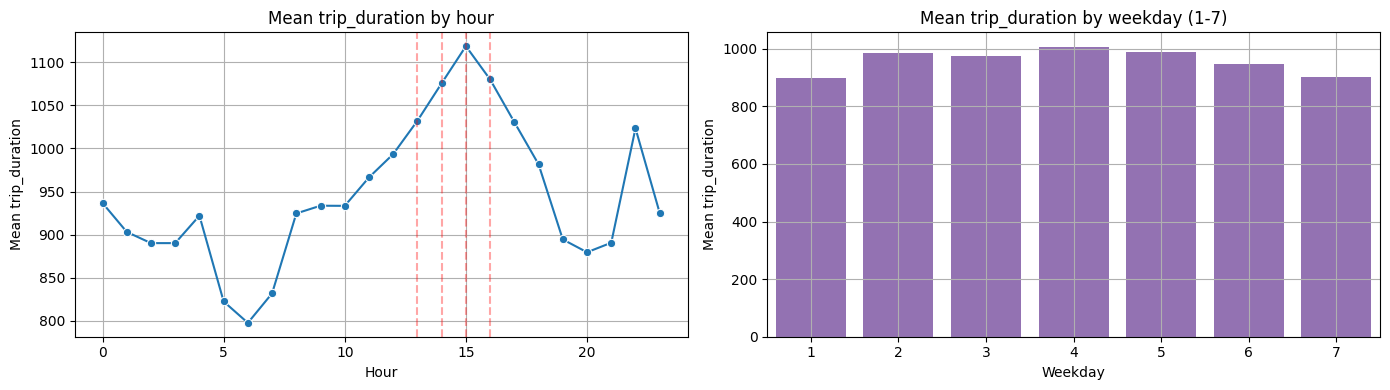

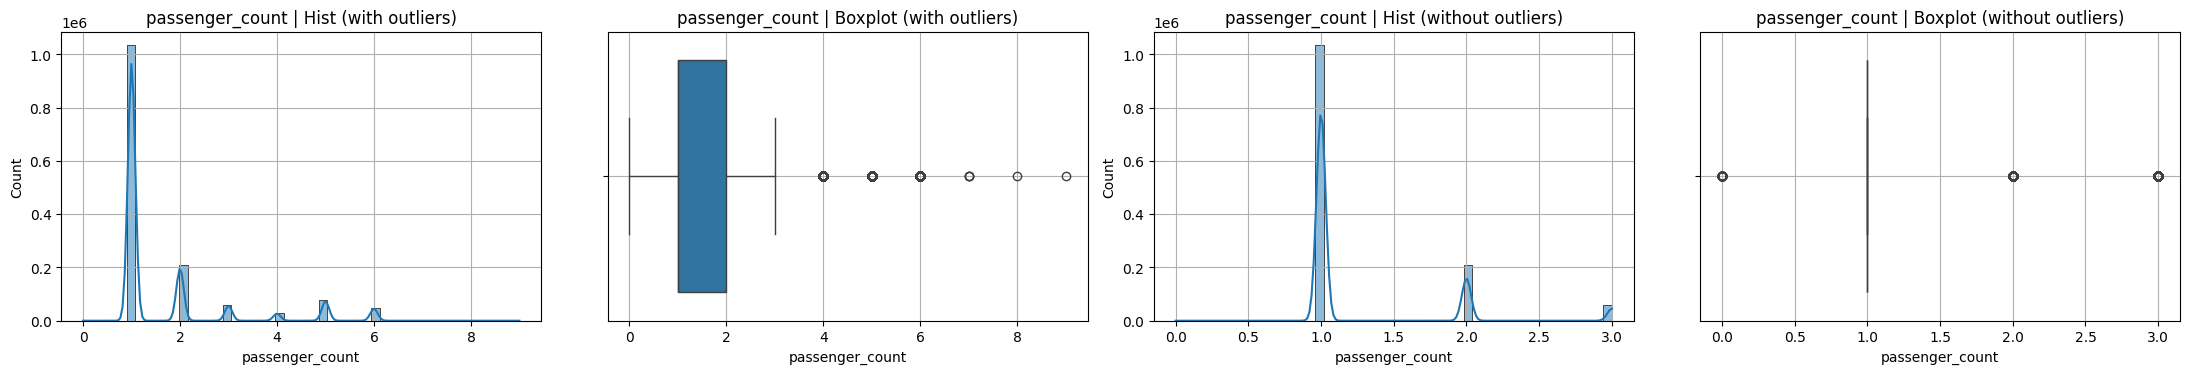

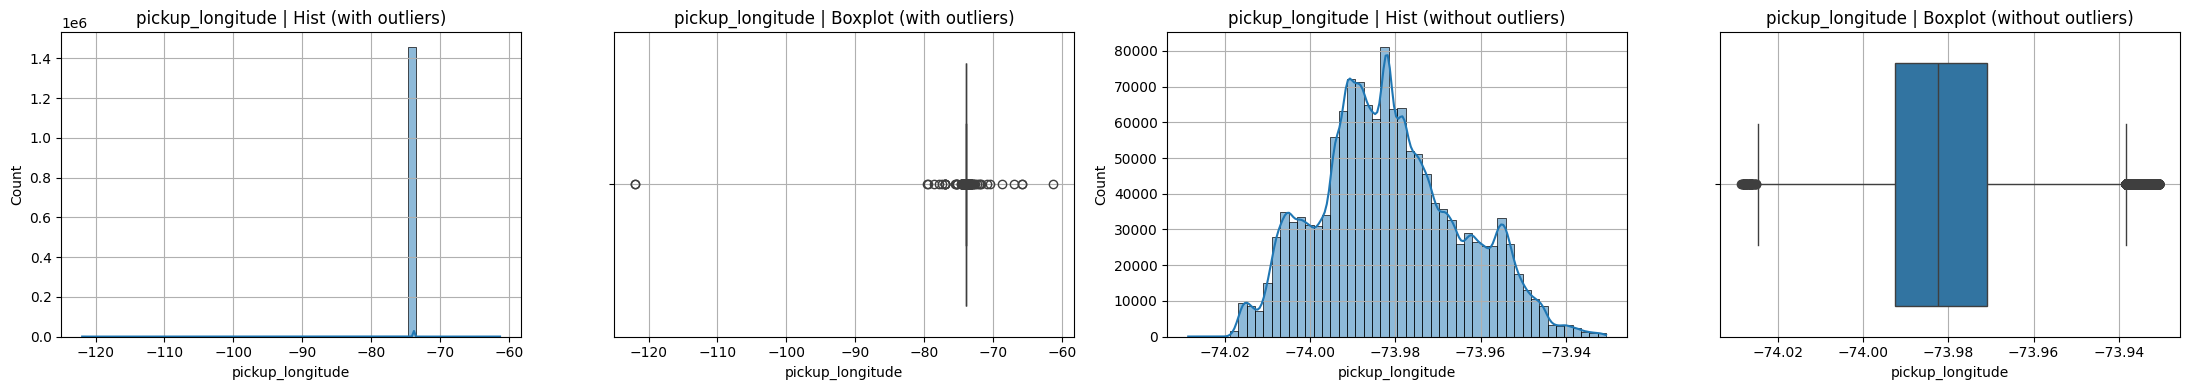

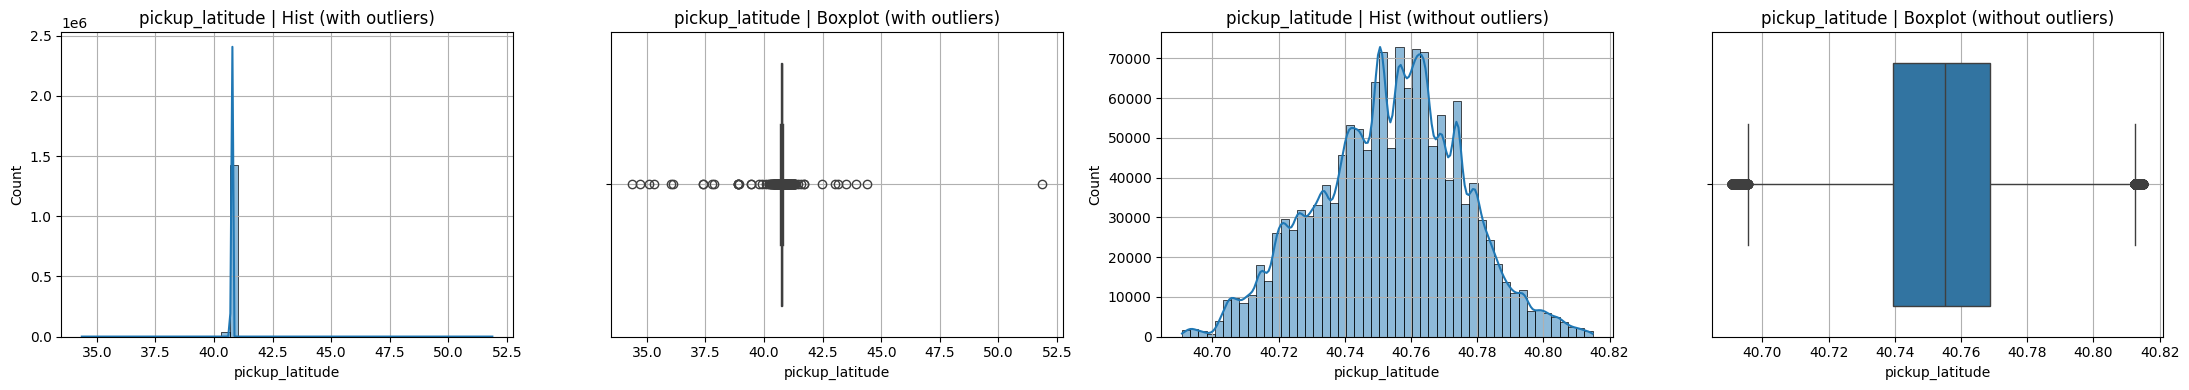

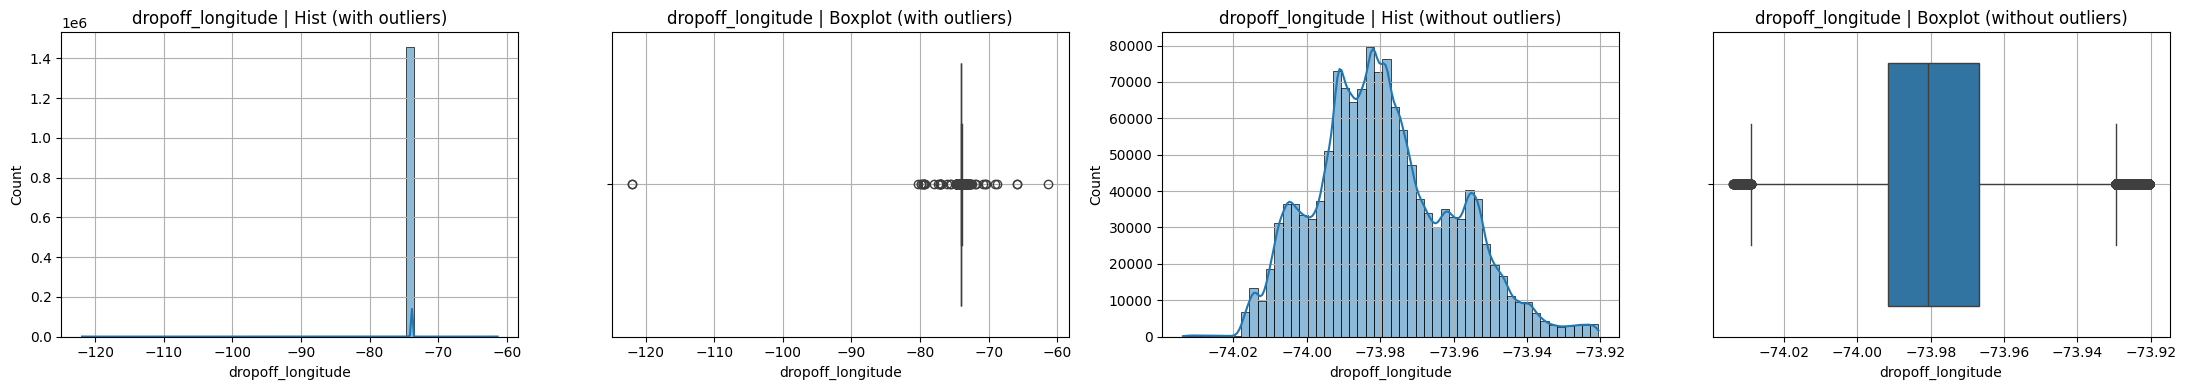

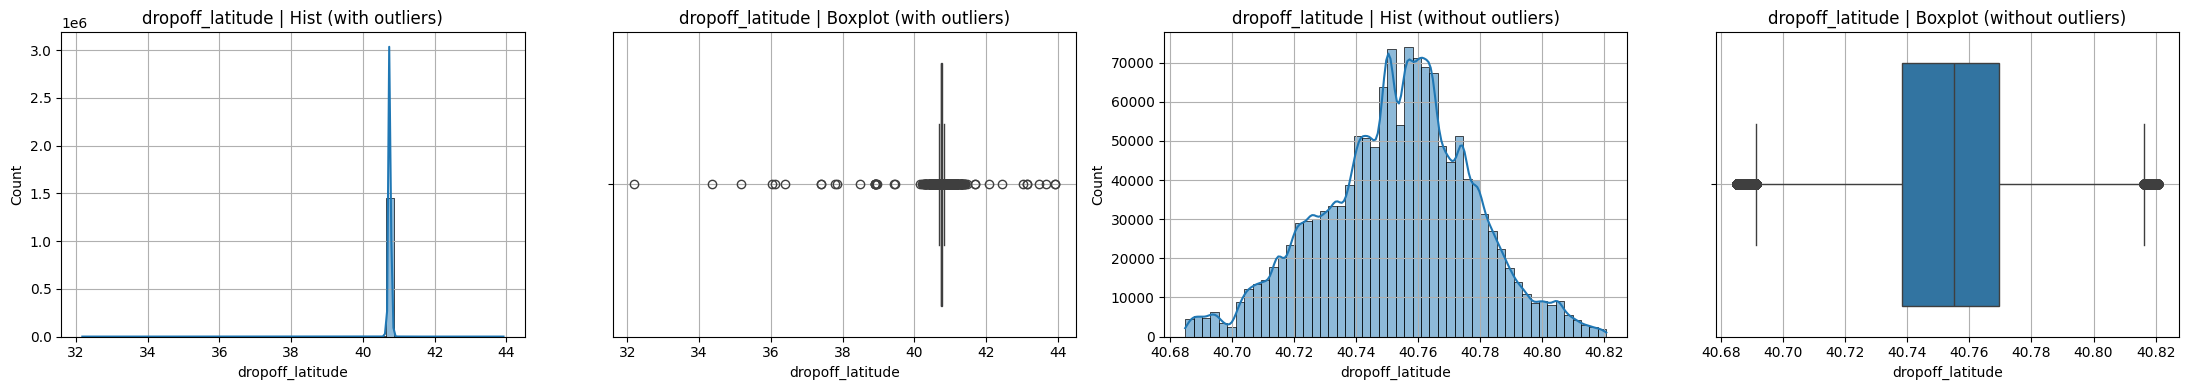

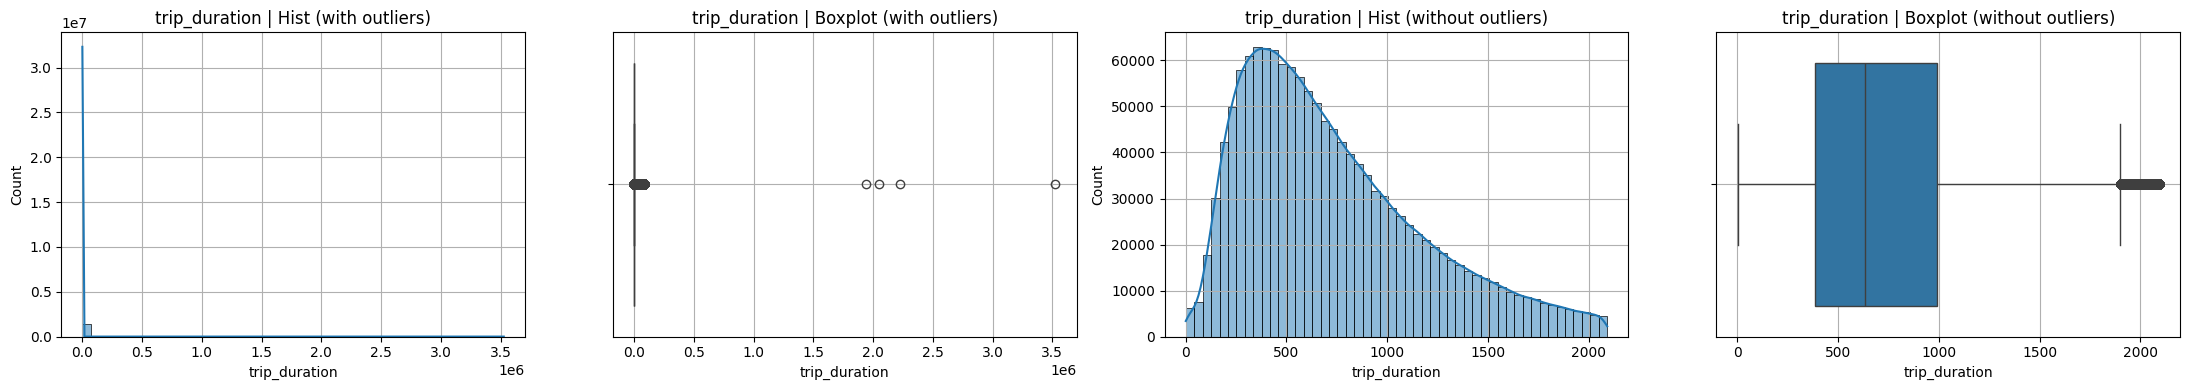

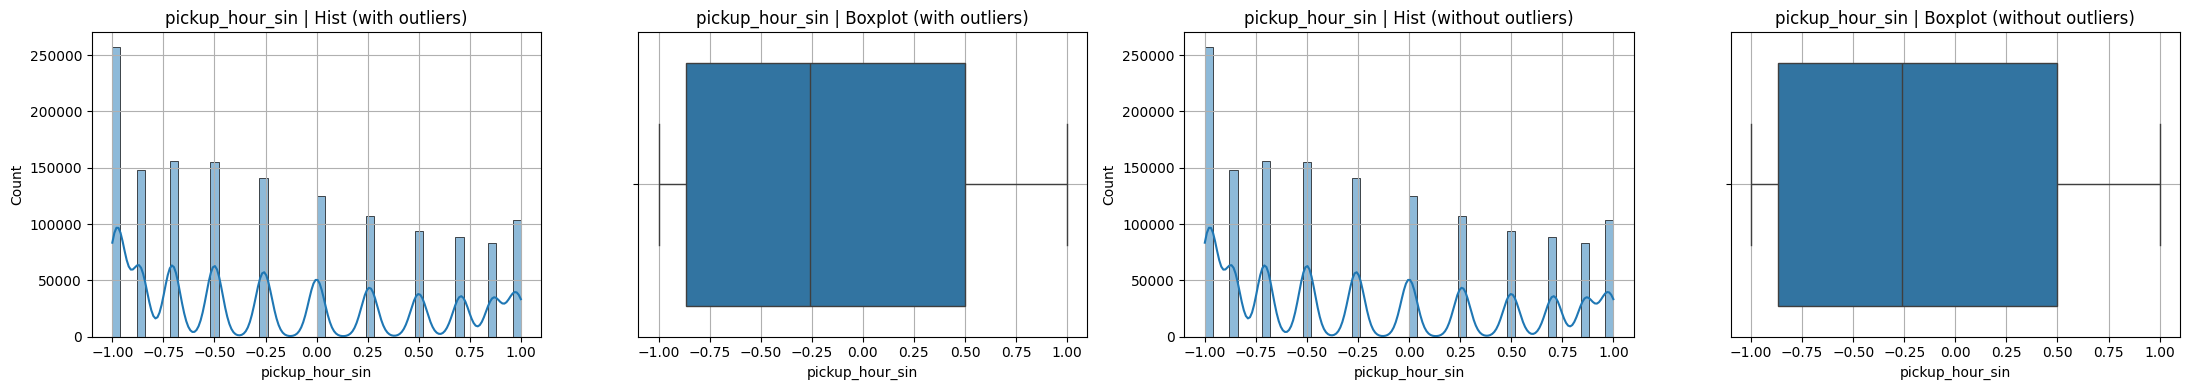

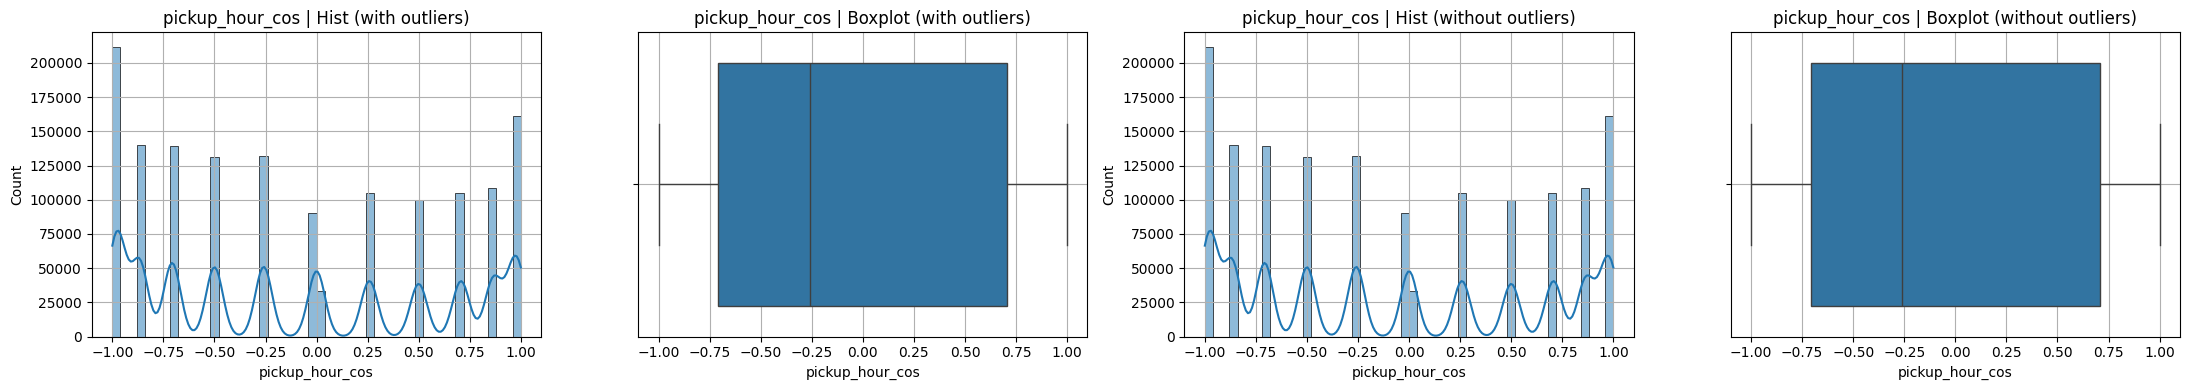

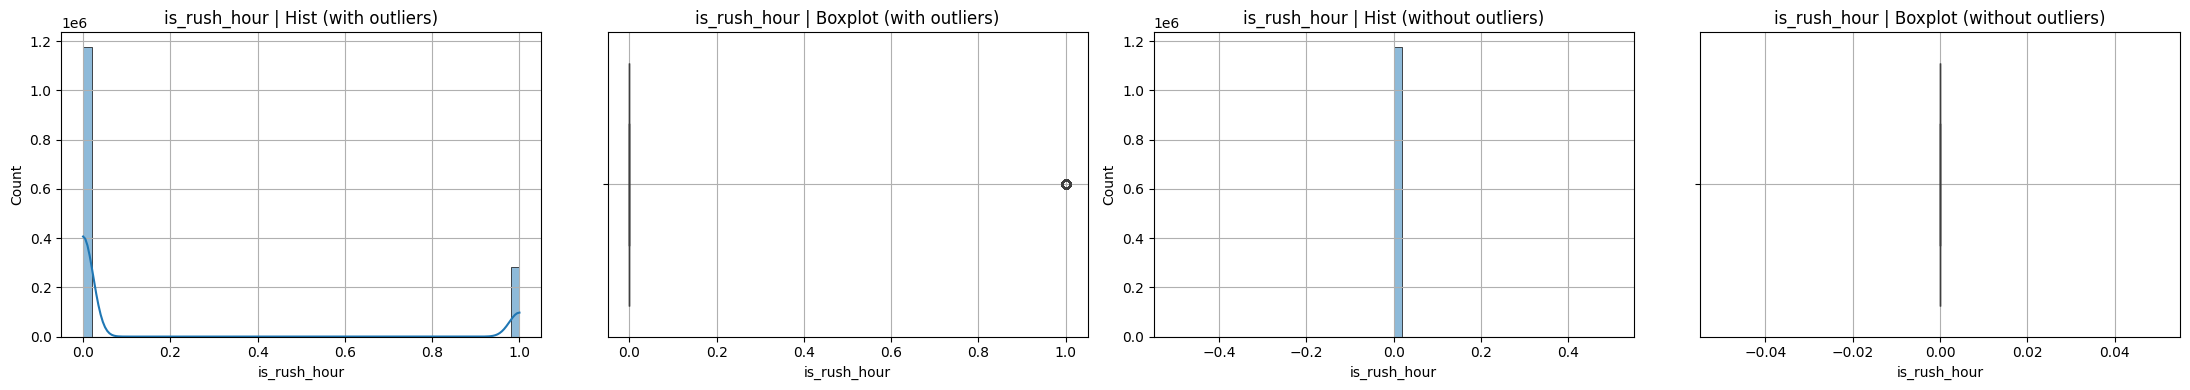

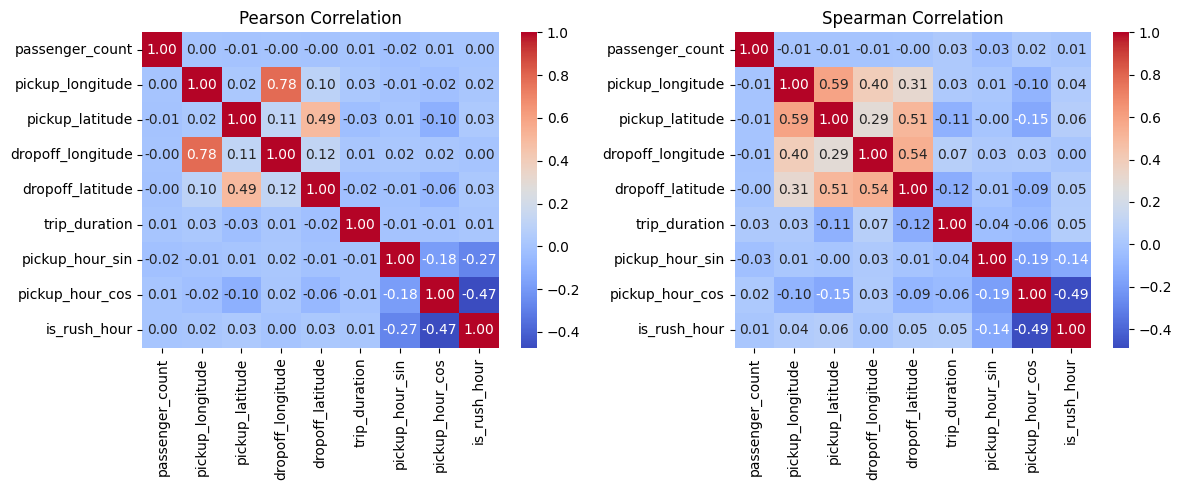

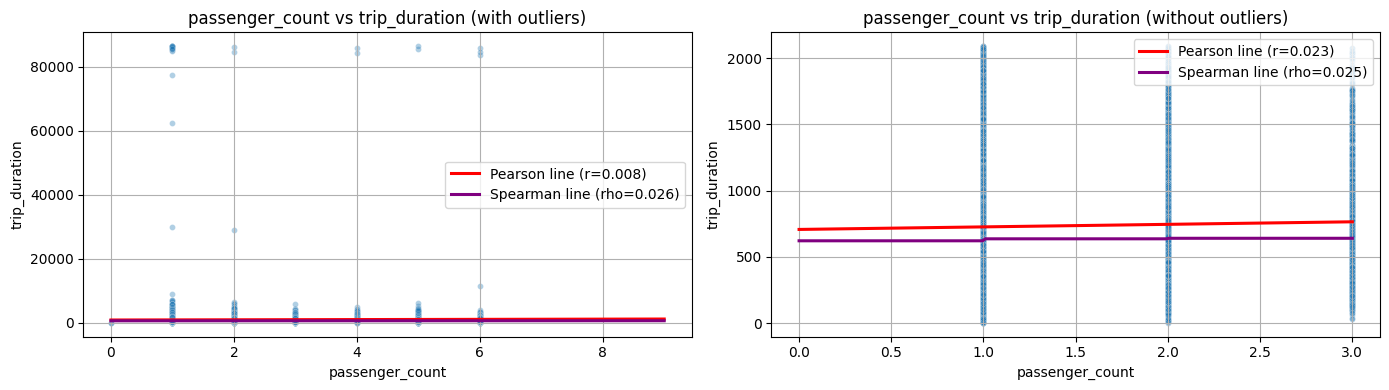

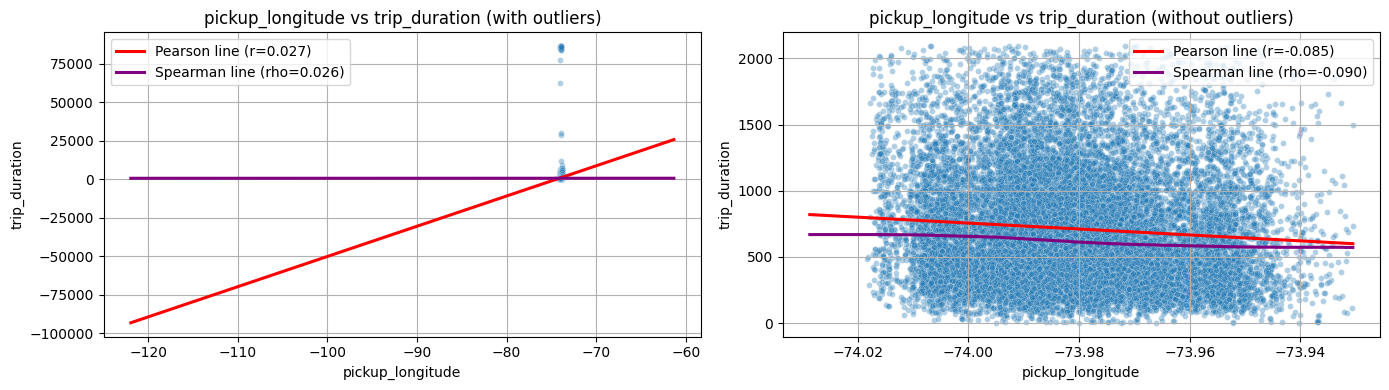

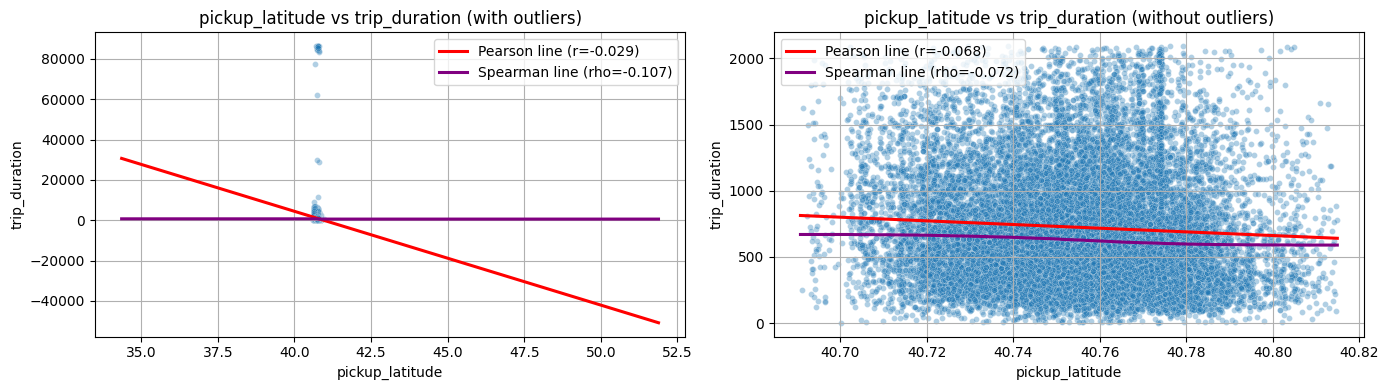

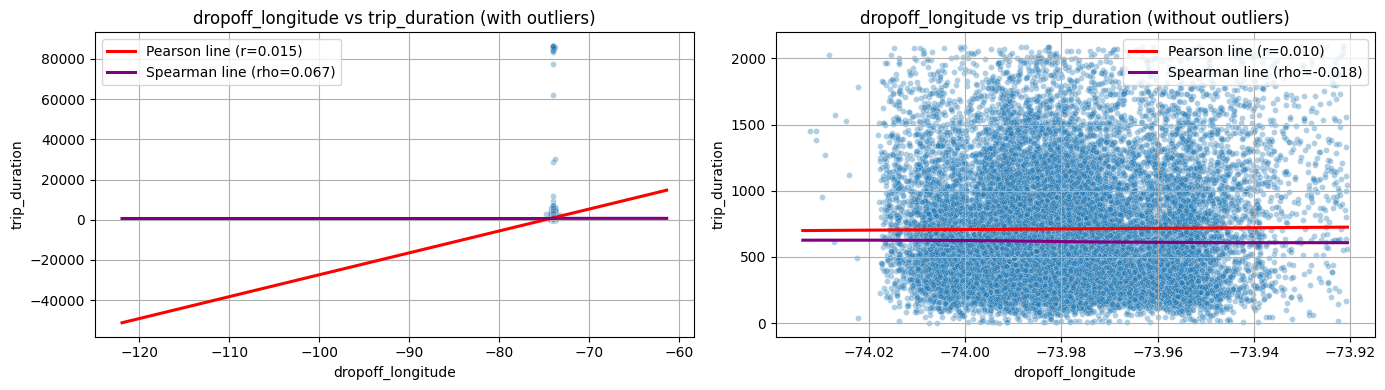

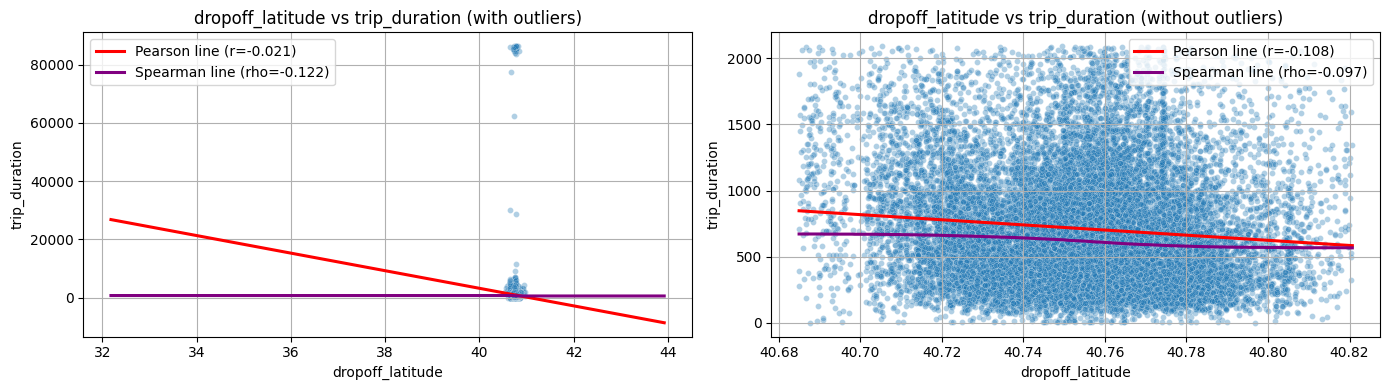

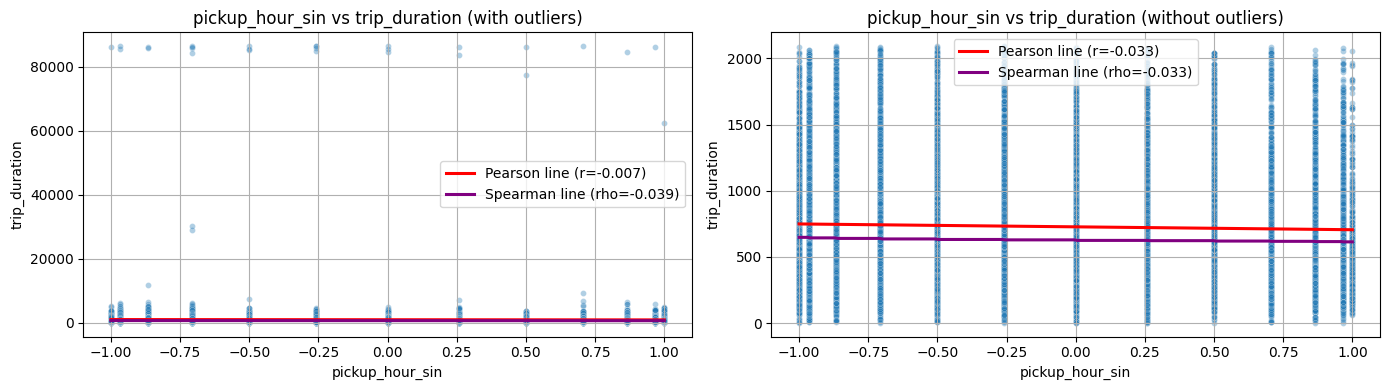

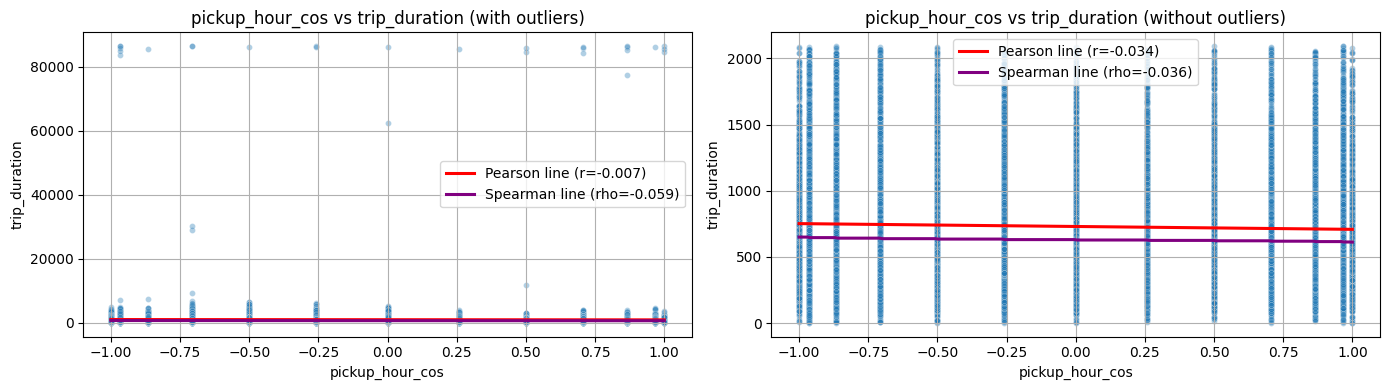

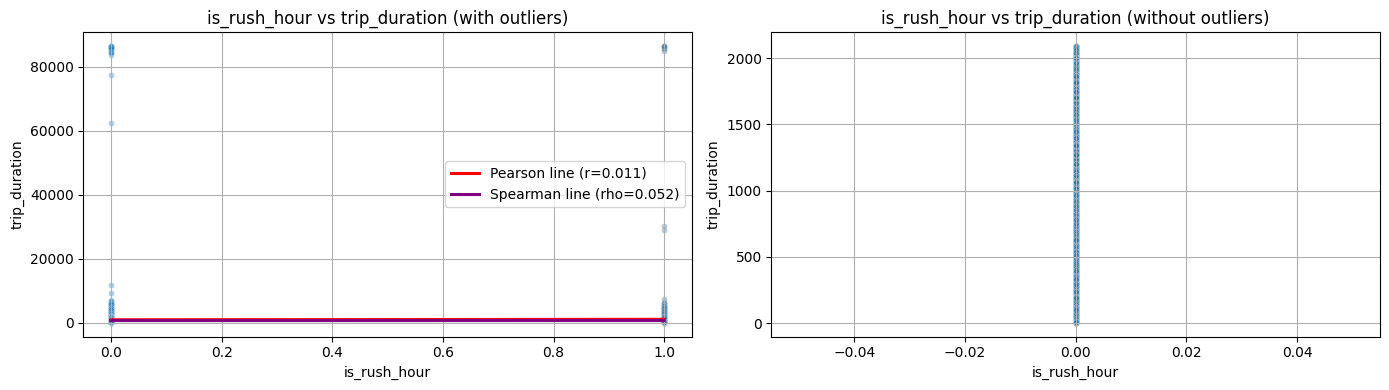

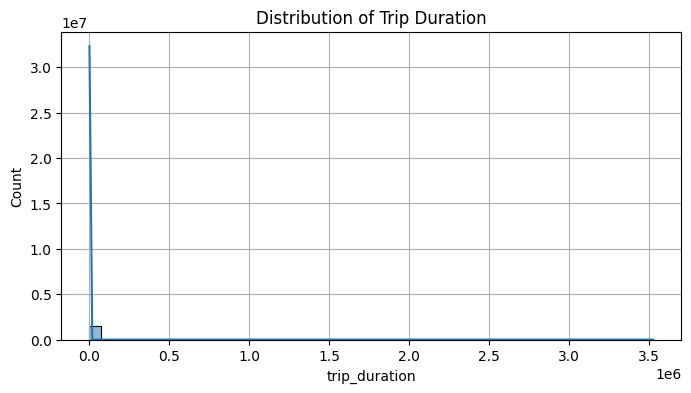

Rush hours selected: [15, 16, 14, 13]


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr


class EDA:

    def __init__(self, train_path=train_path):
        self.df_train = pd.read_csv(train_path).drop(columns=["vendor_id"])
        self.rush_hours = []

    def create_temporal_features(self):
        self.df_train["pickup_datetime"] = pd.to_datetime(
            self.df_train["pickup_datetime"], errors="coerce"
        )

        # Day-of-week in range 1..7 (Mon=1, Sun=7)
        self.df_train["pickup_weekday_1_7"] = (
            self.df_train["pickup_datetime"].dt.weekday + 1
        )

        # Hour of day
        self.df_train["pickup_hour"] = self.df_train["pickup_datetime"].dt.hour

        # Cyclical encoding for hour
        self.df_train["pickup_hour_sin"] = np.sin(
            2 * np.pi * self.df_train["pickup_hour"] / 24
        )
        self.df_train["pickup_hour_cos"] = np.cos(
            2 * np.pi * self.df_train["pickup_hour"] / 24
        )

    def add_rush_hour_features(self, top_k=4, min_rides=500):
        temp = self.df_train.dropna(subset=["pickup_hour", "trip_duration"]).copy()
        if temp.empty:
            self.df_train["is_rush_hour"] = 0
            self.rush_hours = []
            return

        hour_stats = temp.groupby("pickup_hour", as_index=False).agg(
            mean_trip_duration=("trip_duration", "mean"),
            ride_count=("trip_duration", "size"),
        )

        hour_stats = hour_stats[hour_stats["ride_count"] >= min_rides]
        if hour_stats.empty:
            self.df_train["is_rush_hour"] = 0
            self.rush_hours = []
            return

        self.rush_hours = (
            hour_stats.sort_values("mean_trip_duration", ascending=False)
            .head(top_k)["pickup_hour"]
            .astype(int)
            .tolist()
        )

        self.df_train["is_rush_hour"] = (
            self.df_train["pickup_hour"].isin(self.rush_hours).astype(int)
        )

    def plot_temporal_patterns(self):
        temp = self.df_train.dropna(
            subset=["pickup_hour", "pickup_weekday_1_7", "trip_duration"]
        ).copy()
        if temp.empty:
            print("Not enough temporal data to plot.")
            return

        hour_profile = temp.groupby("pickup_hour")["trip_duration"].mean().reset_index()
        weekday_profile = (
            temp.groupby("pickup_weekday_1_7")["trip_duration"].mean().reset_index()
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        sns.lineplot(
            data=hour_profile,
            x="pickup_hour",
            y="trip_duration",
            marker="o",
            ax=axes[0],
            color="tab:blue",
        )
        axes[0].set_title("Mean trip_duration by hour")
        axes[0].set_xlabel("Hour")
        axes[0].set_ylabel("Mean trip_duration")
        axes[0].grid(True)

        if self.rush_hours:
            for h in self.rush_hours:
                axes[0].axvline(h, color="red", linestyle="--", alpha=0.35)

        sns.barplot(
            data=weekday_profile,
            x="pickup_weekday_1_7",
            y="trip_duration",
            ax=axes[1],
            color="tab:purple",
        )
        axes[1].set_title("Mean trip_duration by weekday (1-7)")
        axes[1].set_xlabel("Weekday")
        axes[1].set_ylabel("Mean trip_duration")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    def show_missing_values(self):
        missing = self.df_train.isnull().sum()
        missing = missing[missing > 0]
        if not missing.empty:
            plt.figure(figsize=(10, 5))
            sns.barplot(x=missing.index, y=missing.values)
            plt.title("Missing Values in Train Set")
            plt.xticks(rotation=45)
            plt.grid(True)
            plt.show()
        else:
            print("No missing values in the train set.")

    def correlations(self):
        self.df_train.hist(bins=50, figsize=(20, 15))
        plt.show()

    def plot_distributions(self):
        numeric_cols = self.df_train.select_dtypes(include=["float64", "int64"]).columns
        for col in numeric_cols:
            series = self.df_train[col].dropna()
            if series.empty:
                continue

            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            series_no_outliers = series[(series >= lower) & (series <= upper)]

            fig, axes = plt.subplots(1, 4, figsize=(22, 4))

            sns.histplot(series, bins=50, kde=True, ax=axes[0])
            axes[0].set_title(f"{col} | Hist (with outliers)")
            axes[0].grid(True)

            sns.boxplot(x=series, ax=axes[1])
            axes[1].set_title(f"{col} | Boxplot (with outliers)")
            axes[1].grid(True)

            sns.histplot(series_no_outliers, bins=50, kde=True, ax=axes[2])
            axes[2].set_title(f"{col} | Hist (without outliers)")
            axes[2].grid(True)

            sns.boxplot(x=series_no_outliers, ax=axes[3])
            axes[3].set_title(f"{col} | Boxplot (without outliers)")
            axes[3].grid(True)

            plt.tight_layout()
            plt.show()

    def _spearman_correlation(self):
        numeric_cols = self.df_train.select_dtypes(include=["float64", "int64"]).columns
        spearman_corr = self.df_train[numeric_cols].corr(method="spearman")
        return spearman_corr

    def _pearson_correlation(self):
        numeric_cols = self.df_train.select_dtypes(include=["float64", "int64"]).columns
        pearson_corr = self.df_train[numeric_cols].corr(method="pearson")
        return pearson_corr

    def correlation_heatmap(self):
        pearson_corr = self._pearson_correlation()
        spearman_corr = self._spearman_correlation()

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Pearson Correlation")
        plt.subplot(1, 2, 2)
        sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Spearman Correlation")
        plt.tight_layout()
        plt.show()

    def see_boxplots(self):
        numeric_cols = self.df_train.select_dtypes(include=["float64", "int64"]).columns
        for col in numeric_cols:
            plt.figure(figsize=(8, 4))
            sns.boxplot(x=self.df_train[col])
            plt.title(f"Boxplot of {col}")
            plt.grid(True)
            plt.show()

    def _draw_corr_lines(self, ax, df_line, col):
        x = df_line[col].to_numpy()
        y = df_line["trip_duration"].to_numpy()

        if len(x) < 3 or np.nanstd(x) == 0:
            return

        x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)

        p_slope, p_intercept = np.polyfit(x, y, 1)
        y_pearson = p_slope * x_line + p_intercept
        r_pearson, _ = pearsonr(x, y)
        ax.plot(
            x_line,
            y_pearson,
            color="red",
            linewidth=2.2,
            label=f"Pearson line (r={r_pearson:.3f})",
        )

        x_order = np.argsort(x)
        y_order = np.argsort(y)
        x_rank = np.empty_like(x_order, dtype=float)
        y_rank = np.empty_like(y_order, dtype=float)
        x_rank[x_order] = np.arange(1, len(x) + 1, dtype=float)
        y_rank[y_order] = np.arange(1, len(y) + 1, dtype=float)

        s_slope, s_intercept = np.polyfit(x_rank, y_rank, 1)
        x_rank_line = np.interp(
            x_line, np.sort(x), np.arange(1, len(x) + 1, dtype=float)
        )
        y_rank_line = s_slope * x_rank_line + s_intercept
        y_rank_line = np.clip(y_rank_line, 1, len(y))
        y_sorted = np.sort(y)
        y_spearman = np.interp(
            y_rank_line, np.arange(1, len(y) + 1, dtype=float), y_sorted
        )

        r_spearman, _ = spearmanr(x, y)
        ax.plot(
            x_line,
            y_spearman,
            color="purple",
            linewidth=2.2,
            label=f"Spearman line (rho={r_spearman:.3f})",
        )
        ax.legend(loc="best")

    def see_scatterplots(self):
        numeric_cols = self.df_train.select_dtypes(include=["float64", "int64"]).columns

        for col in numeric_cols:
            if col == "trip_duration":
                continue

            df_plot = self.df_train[[col, "trip_duration"]].dropna().copy()
            if df_plot.empty:
                continue

            q1_x = df_plot[col].quantile(0.25)
            q3_x = df_plot[col].quantile(0.75)
            iqr_x = q3_x - q1_x
            lower_x = q1_x - 1.5 * iqr_x
            upper_x = q3_x + 1.5 * iqr_x

            q1_y = df_plot["trip_duration"].quantile(0.25)
            q3_y = df_plot["trip_duration"].quantile(0.75)
            iqr_y = q3_y - q1_y
            lower_y = q1_y - 1.5 * iqr_y
            upper_y = q3_y + 1.5 * iqr_y

            df_no_outliers = df_plot[
                (df_plot[col] >= lower_x)
                & (df_plot[col] <= upper_x)
                & (df_plot["trip_duration"] >= lower_y)
                & (df_plot["trip_duration"] <= upper_y)
            ]

            # Sample only for points visualization
            sample_n = min(20000, len(df_plot))
            with_out = (
                df_plot.sample(n=sample_n, random_state=42)
                if len(df_plot) > sample_n
                else df_plot
            )
            without_out = (
                df_no_outliers.sample(n=sample_n, random_state=42)
                if len(df_no_outliers) > sample_n
                else df_no_outliers
            )

            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            sns.scatterplot(
                data=with_out,
                x=col,
                y="trip_duration",
                ax=axes[0],
                alpha=0.35,
                s=18,
            )
            self._draw_corr_lines(axes[0], df_plot, col)
            axes[0].set_title(f"{col} vs trip_duration (with outliers)")
            axes[0].grid(True)

            sns.scatterplot(
                data=without_out,
                x=col,
                y="trip_duration",
                ax=axes[1],
                alpha=0.35,
                s=18,
            )
            if not without_out.empty:
                self._draw_corr_lines(axes[1], df_no_outliers, col)
            axes[1].set_title(f"{col} vs trip_duration (without outliers)")
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

    def target_distribution(self):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df_train["trip_duration"], bins=50, kde=True)
        plt.title("Distribution of Trip Duration")
        plt.grid(True)
        plt.show()

    def run_all(self):
        self.create_temporal_features()
        self.add_rush_hour_features(top_k=4, min_rides=500)
        self.show_missing_values()
        self.plot_temporal_patterns()
        self.plot_distributions()
        self.correlation_heatmap()
        self.see_scatterplots()
        self.target_distribution()


eda_analysis = EDA(train_path=train_path)
eda_analysis.run_all()
print(f"Rush hours selected: {eda_analysis.rush_hours}")